In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cardekho.csv to cardekho.csv


In [3]:
data = pd.read_csv("cardekho.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [4]:
data['mileage(km/ltr/kg)'] = data['mileage(km/ltr/kg)'].astype(str).str.split().str[0]
data['mileage(km/ltr/kg)'] = pd.to_numeric(data['mileage(km/ltr/kg)'], errors='coerce')

data = data.dropna()

In [5]:
X = data[['km_driven']]
Y = data['selling_price']

In [6]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_poly, Y, test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [9]:
Y_pred = model.predict(X_test)
print(Y_pred[:10])

[642852.99687216 446267.69913932 134238.47675585 537923.39024386
 913311.8511444  608999.4463071  657495.04927061 244315.71419567
 746017.41100797 561393.095814  ]


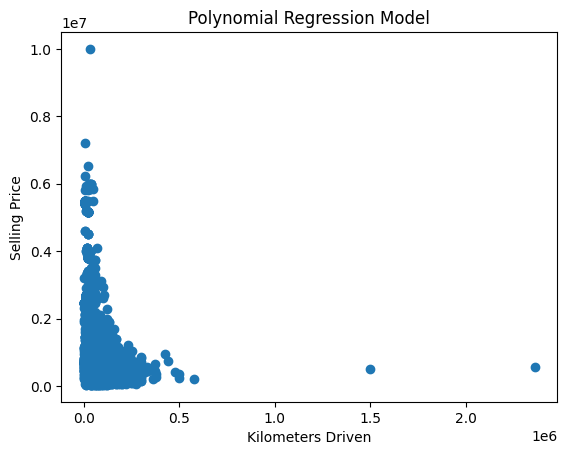

In [10]:
plt.scatter(X, Y)

plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

plt.title("Polynomial Regression Model")

plt.show()